In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import random
import pickle

from sklearn.cluster import SpectralClustering

from torchvision.datasets import MNIST

from dataset_builder import *
from clustering_utils import *
from Siamese_networks import *
from training_functions import *

In [25]:
train_loader, test_loader, mnist = prepare_mnist_data_couples(subset_ratio = 1, train_ratio=0.75, batchsize=128)

Dataset preparato:
- Subset totale: 60000 campioni
- Training set: 45000 campioni
- Test set: 15000 campioni
- Batch size: 128


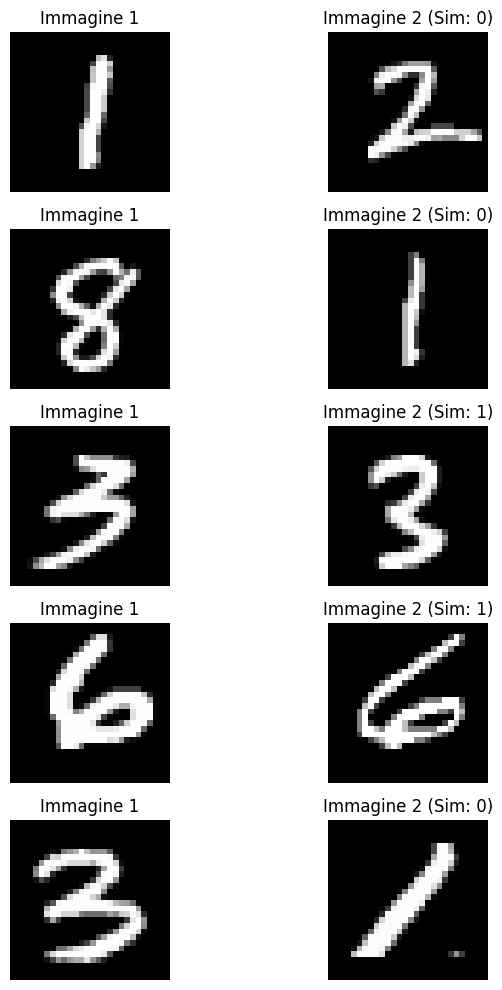

In [5]:
visualize_pairs(train_loader.dataset)

In [ ]:
net = SiameseNetwork_Couple(embedding_size = 64)
criterion = ContrastiveWeightedLoss(margin=2.0, w = 1)
optimizer = torch.optim.Adam(net.parameters(), lr = 0.00001)

counter, loss_history = train_couple_model(net, train_loader, optimizer, criterion, epochs = 20)


Epoch 0 batch 0
loss 0.8052181601524353

Epoch 0 batch 50
loss 0.6494677066802979

Epoch 1 batch 0
loss 0.6630192399024963

Epoch 1 batch 50
loss 0.5395370125770569

Epoch 2 batch 0
loss 0.5594260096549988

Epoch 2 batch 50
loss 0.537153422832489

Epoch 3 batch 0
loss 0.5345017313957214

Epoch 3 batch 50
loss 0.5536913871765137

Epoch 4 batch 0
loss 0.5329017043113708

Epoch 4 batch 50
loss 0.5482187271118164

Epoch 5 batch 0
loss 0.5311009883880615

Epoch 5 batch 50
loss 0.5507034063339233

Epoch 6 batch 0
loss 0.5351160168647766

Epoch 6 batch 50
loss 0.5447672605514526

Epoch 7 batch 0
loss 0.5345244407653809

Epoch 7 batch 50
loss 0.5401508808135986

Epoch 8 batch 0
loss 0.5314702987670898

Epoch 8 batch 50
loss 0.5223910212516785

Epoch 9 batch 0
loss 0.5322027802467346

Epoch 9 batch 50
loss 0.5266230702400208

Epoch 10 batch 0
loss 0.5298770666122437

Epoch 10 batch 50
loss 0.513596773147583

Epoch 11 batch 0
loss 0.525101900100708

Epoch 11 batch 50
loss 0.5251467823982239

Epo

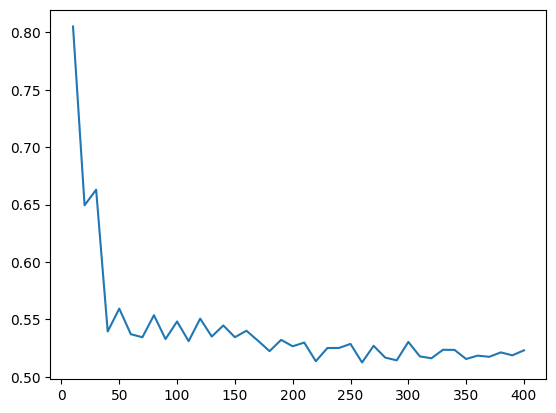

In [16]:
plt.plot(counter, loss_history)

In [ ]:
_ = test_couple_model(net, test_loader.dataset, num_examples=100)

Test del modello su 100 esempi:
------------------------------------------------------------
Il modello ne ha beccate: 60
Il modello ne ha sbagliate: 40


In [19]:
campioni = 100
tests = [test_trained_model(net, test_loader.dataset, num_examples=100, verbose=False) for i in range(campioni)]

print("Accuracy media: " +str(np.mean(tests)))
print("Varianza accuracy: " + str(np.var(tests)))

Accuracy media: 0.5617
Varianza accuracy: 0.0022961099999999996


In [20]:
test_accuracy = test_trained_model(net, test_loader.dataset, num_examples=len(test_loader.dataset))

Test del modello su 3000 esempi:
------------------------------------------------------------
Il modello ne ha beccate: 1674
Il modello ne ha sbagliate: 1326


In [ ]:

# salvataggio modello
# with open("models/SSN (56acc-128bs).pkl", "wb") as f:
#     pickle.dump(net, f)

---


## Spectral clustering on embeddings

In [3]:
with open("models\SSN (56acc-128bs).pkl", "rb") as f:
    SiameseNet = pickle.load(f)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_34844\473068957.py:1: SyntaxWarning: invalid escape sequence '\S'
  with open("models\SSN (56acc-128bs).pkl", "rb") as f:


In [4]:
def create_embedding_dataset(model, data_loader):
    """
    Crea un dataset di embedding usando la rete siamese allenata
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            data = data.to(device)
            
            # Genera embedding usando forward_once
            embedding = model.forward_once(data)
            
            embeddings.append(embedding.cpu().numpy())
            labels.extend(target.numpy())
            
            if batch_idx % 100 == 0:
                print(f'Processato batch {batch_idx}/{len(data_loader)}')
    
    embeddings = np.vstack(embeddings)
    labels = np.array(labels)
    
    return embeddings, labels


In [5]:
def MNIST_data_loader():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    dataset = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)
    data_loader = DataLoader(dataset, batch_size=256, shuffle=False)
    return data_loader


In [6]:
embedding_set, labels = create_embedding_dataset(SiameseNet, MNIST_data_loader())

Processato batch 0/40


In [7]:
len(embedding_set)

10000

In [ ]:
n_clusters = 10  # ad esempio per MNIST

clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',  # usa k-NN per costruire il grafo di similarità
    assign_labels='kmeans',        # metodo per l’assegnazione finale dei cluster
    random_state=0
)

cluster_labels = clustering.fit_predict(embedding_set)


Applicando t-SNE per visualizzazione...


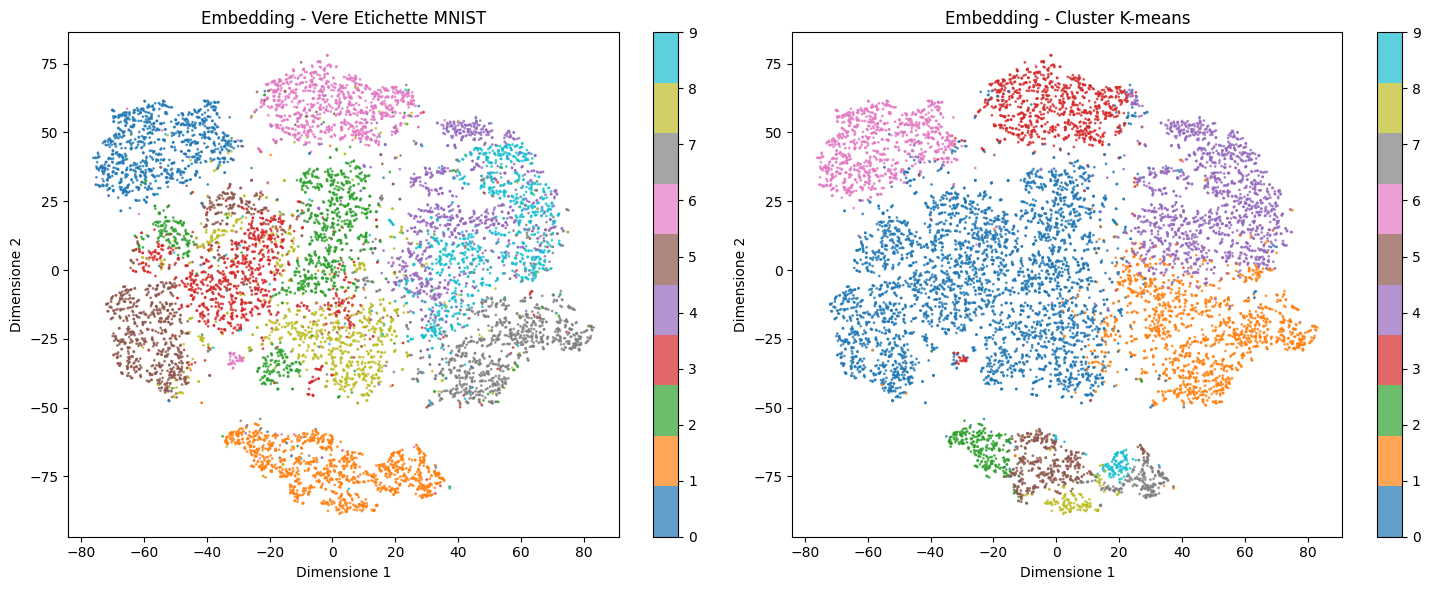

In [12]:
visualize_embeddings(embeddings = embedding_set, embedding_size=64, true_labels=labels, cluster_labels = cluster_labels)

In [13]:
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
data = mnist.data.numpy().reshape(len(mnist), -1) / 255.0  # shape (60000, 784)
labels = mnist.targets.numpy()

n_clusters = 10  # ad esempio per MNIST

clustering = SpectralClustering(
    n_clusters=n_clusters,
    affinity='nearest_neighbors',  # usa k-NN per costruire il grafo di similarità
    assign_labels='kmeans',        # metodo per l’assegnazione finale dei cluster
    random_state=0
)

cluster_labels = clustering.fit_predict(data)


Applicando t-SNE per visualizzazione...


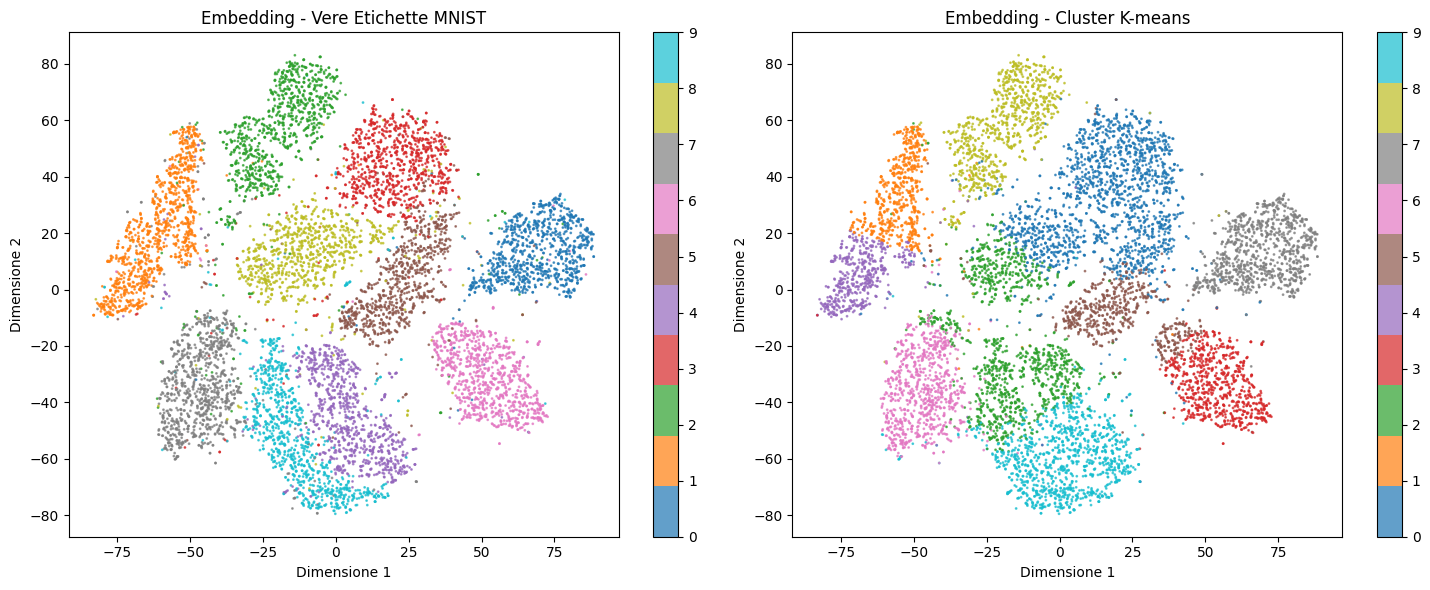

In [15]:
visualize_embeddings(embeddings = data, embedding_size=len(data[0]), true_labels=labels, cluster_labels = cluster_labels)